# TF-QKD Channel Model — Phase 1
### Based on: *Simple security proof of twin-field type quantum key distribution protocol*
### Curty, Azuma & Lo (2018) · arXiv:1807.07667v2

---
**Author:** Anand Ambastha  
**Phase:** 1 — Channel model foundation, gain equations, photon-number yields, Eq. (35)  
**Status:** Research-grade implementation — no key rate optimisation in this phase

---

## 1 · Introduction

### 1.1 Twin-Field QKD and the Square-Root Scaling

Classical point-to-point QKD is fundamentally limited by the PLOB bound [Pirandola et al., 2017],
which states that the secret key rate $R$ scales **linearly** with the channel transmittance $\eta$:
$$R \lesssim -\log_2(1-\eta) \approx \eta \quad (\eta \ll 1).$$
For a 1000 km telecom fibre (0.2 dB/km loss) this renders practical QKD essentially impossible
without trusted or quantum repeater nodes.

**Twin-Field (TF) QKD** [Lucamarini et al., 2018] is a radical departure: it exploits
*single-photon interference* at a central measurement station $C$, so that a detection event
requires only **one** photon to travel half the total distance.  
As a result the key rate scales as $\sqrt{\eta}$ — a dramatic improvement that can beat the PLOB bound.

### 1.2 Why TF-QKD differs from MDI-QKD

Standard MDI-QKD relies on **two-photon coincidence** events: one photon from Alice and one from
Bob must arrive at $C$ simultaneously and interfere.  The success probability therefore scales as
$\eta_A \times \eta_B \sim \eta$.  
TF-QKD needs only a **single** photon (from either Alice or Bob) to reach $C$, giving a success
probability $\sim \sqrt{\eta}$.

### 1.3 Protocol 3 (Curty-Azuma-Lo 2018)

The paper introduces three conceptually nested protocols.  **Protocol 3** is the practically
realisable version:

| Basis | State | Purpose |
|-------|-------|----------|
| X (key gen.) | Coherent states $|\pm\alpha\rangle$ | Raw key bits |
| Z (test) | Phase-randomised coherent states $\hat{\rho}_{\beta}$ | Decoy-state estimation |

- **Local** phase randomisation only — no global-phase matching needed.
- Security proved via Koashi's complementarity framework.
- Key rate lower bound: $R^{\mathrm{low}}_X = R^{\mathrm{low}}_{X,10} + R^{\mathrm{low}}_{X,01}$
  (Eqs. 16–19 of the paper).

### 1.4 Gains and Yields — notation guide

| Symbol | Meaning |
|--------|---------|
| $p_{XX}(k_c,k_d\mid b_A,b_B)$ | X-basis gain: prob. of detector pattern $(k_c,k_d)$ given bits $b_A,b_B$ |
| $p_{XX}(k_c,k_d)$ | Marginal X-basis gain (averaged over bits) |
| $e_{X,k_ck_d}$ | X-basis bit-error rate |
| $p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ | Z-basis gain for coherent amplitudes $\beta_A,\beta_B$ |
| $p_{ZZ}(k_c,k_d\mid n_A,n_B)$ | Photon-number yield (Fock inputs $n_A,n_B$) |
| $\gamma$ | Effective channel parameter $\gamma = \sqrt{\eta}\,\alpha^2$ |

Throughout, **only events with $k_c \oplus k_d = 1$** (exactly one detector fires) are accepted
as valid sifted rounds.  All equations in the paper's Appendix are written under this convention.

### 1.5 Scope of Phase 1

This notebook builds the **channel model foundation**:
- Binary entropy, omega function, $f^\pm$
- X-basis gains ($p_{XX}$, $q_{XX}$, $e_X$) — Eqs. (27)–(31)
- Z-basis gains ($p_{ZZ}$, $q_{ZZ}$) — Eqs. (32)–(33)
- Photon-number yields — Eq. (34)
- Modular decomposition of Eq. (35)
- Sanity checks and diagnostic plots

**Not in Phase 1:** finite decoy LP (Eq. 26), phase-error upper bound (Eq. 20–21),
key rate optimisation.

## 2 · Theory Overview

### Key equations implemented in this notebook

$$\Omega(\phi,\theta) = \cos\phi\cos\theta \tag{Appendix}$$

$$f^\pm_{(\theta,\phi,\gamma)} = e^{-\gamma[1 \pm \Omega(\phi,\theta)]} - e^{-2\gamma} \tag{29}$$

$$q_{XX}(k_c,k_d\mid b_A,b_B) = \begin{cases} f^- & k_c\oplus b_A \oplus b_B = 1 \\ f^+ & k_c\oplus b_A \oplus b_B = 0 \end{cases} \tag{28}$$

$$p_{XX}(k_c,k_d\mid b_A,b_B) = (1-p_d)\left[p_d\,e^{-2\gamma} + q_{XX}(k_c,k_d\mid b_A,b_B)\right] \tag{27}$$

$$p_{XX}(k_c,k_d) = \tfrac{1}{2}(1-p_d)\left(e^{-\gamma\Omega}+e^{\gamma\Omega}\right)e^{-\gamma} - (1-p_d)^2 e^{-2\gamma} \tag{30}$$

$$e_{X,k_ck_d} = \frac{e^{-\gamma\Omega} - (1-p_d)e^{-\gamma}}{e^{-\gamma\Omega}+e^{\gamma\Omega} - 2(1-p_d)e^{-\gamma}} \tag{31}$$

$$p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B) = (1-p_d)\left[p_d\,e^{-(\beta_A^2+\beta_B^2)\sqrt{\eta}} + q_{ZZ}\right] \tag{32}$$

$$q_{ZZ}(k_c,k_d\mid\beta_A,\beta_B) = e^{-\frac{(\beta_A^2+\beta_B^2)\sqrt{\eta}}{2}}I_0(\beta_A\beta_B\sqrt{\eta}\cos\theta) - e^{-(\beta_A^2+\beta_B^2)\sqrt{\eta}} \tag{33}$$

$$p_{ZZ}(k_c,k_d\mid n_A,n_B) = (1-p_d)\left[p_d(1-\sqrt{\eta})^{n_A+n_B} + q_{ZZ}(k_c,k_d\mid n_A,n_B)\right] \tag{34}$$

The full form of $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ is given by Eq. (35) — a nested combinatorial sum
over beam-splitter output modes — implemented modularly below.

## 3 · Imports

In [1]:
# ─────────────────────────────────────────────────────────────
# Standard scientific stack — all available in Google Colab
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

from scipy.special import (
    i0 as bessel_i0,   # Modified Bessel function I_0(z) — used in q_ZZ
    comb,              # Binomial coefficient C(n, k) with exact integer arithmetic
    factorial,         # k!  (float64 for moderate k)
)

warnings.filterwarnings('ignore', category=RuntimeWarning)  # suppress log(0) warnings

# Pretty plots
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'lines.linewidth': 1.8,
})

print('Imports OK — numpy', np.__version__)

Imports OK — numpy 2.0.2


## 4 · Global Simulation Parameters

All physical parameters live in one dictionary — modify here to run different scenarios.

In [2]:
# ─────────────────────────────────────────────────────────────
# GLOBAL SIMULATION PARAMETERS
# Reference: Appendix of Curty-Azuma-Lo 2018
# ─────────────────────────────────────────────────────────────

PARAMS = dict(
    # ── Detector dark-count probability per pulse ──────────────
    pd = 1e-7,

    # ── Signal amplitude α > 0 for X-basis coherent states ────
    # (γ = sqrt(η) · α²  is derived from this)
    alpha = 0.2,

    # ── Polarisation misalignment angles [radians] ─────────────
    # Paper uses θ_A = -θ_B = arcsin(√0.02)  ≈ 8.13° ≈ 2% misalignment
    thetaA =  np.arcsin(np.sqrt(0.02)),   # Alice–C channel
    thetaB = -np.arcsin(np.sqrt(0.02)),   # Bob–C  channel

    # ── Phase-mismatch parameter δ  (φ = δ·π) ─────────────────
    # δ = 0 → no phase mismatch (used in Fig. 1 of the paper)
    delta = 0.0,

    # ── Loss sweep: overall Alice–Bob loss in dB ───────────────
    # Note: η here is the *total* transmittance Alice→Bob;
    # each half-link has transmittance √η.
    loss_dB_range = np.linspace(0, 120, 300),
)

# ── Derived convenience: composite misalignment angle ─────────
PARAMS['theta'] = PARAMS['thetaA'] - PARAMS['thetaB']   # θ = θ_A − θ_B
PARAMS['phi']   = PARAMS['delta'] * np.pi                # φ = δ·π

# ── Helper: convert dB loss to transmittance η ────────────────
def dB_to_eta(loss_dB: np.ndarray) -> np.ndarray:
    """Overall transmittance η = 10^(−loss_dB / 10).

    Each Alice–C and Bob–C half-link has transmittance √η.
    """
    return 10.0 ** (-np.asarray(loss_dB, dtype=np.float64) / 10.0)


# ── Quick summary ──────────────────────────────────────────────
print('Global parameters:')
for k, v in PARAMS.items():
    if k == 'loss_dB_range':
        print(f'  {k:20s}: linspace({v[0]:.0f}, {v[-1]:.0f}, {len(v)})')
    elif isinstance(v, float):
        print(f'  {k:20s}: {v:.6g}')
    else:
        print(f'  {k:20s}: {v}')

Global parameters:
  pd                  : 1e-07
  alpha               : 0.2
  thetaA              : 0.141897
  thetaB              : -0.141897
  delta               : 0
  loss_dB_range       : linspace(0, 120, 300)
  theta               : 0.283794
  phi                 : 0


## 5 · Binary Entropy Function

$$h(x) = -x\log_2 x - (1-x)\log_2(1-x), \quad x\in[0,1]$$

Special cases: $h(0) = h(1) = 0$ (by continuity / L'Hôpital).

In [3]:
def h(x: np.ndarray) -> np.ndarray:
    """Binary entropy  h(x) = -x log2(x) - (1-x) log2(1-x).

    Numerically safe:
    - Returns 0 at x = 0 or x = 1  (boundary convention).
    - Clips x to [0, 1] to guard against tiny numerical over/underflow.
    - Vectorised over numpy arrays.

    Parameters
    ----------
    x : float or ndarray
        Probability value(s) in [0, 1].

    Returns
    -------
    ndarray  — binary entropy, range [0, 1] bits.
    """
    x = np.asarray(x, dtype=np.float64)
    x = np.clip(x, 0.0, 1.0)

    # np.where avoids 0*log(0) = nan; both 0·(-inf) branches return 0
    term1 = np.where(x   > 0.0, -x       * np.log2(np.where(x   > 0.0, x,   1.0)), 0.0)
    term2 = np.where(1-x > 0.0, -(1.0-x) * np.log2(np.where(1-x > 0.0, 1-x, 1.0)), 0.0)
    return term1 + term2


# ── Quick validation ───────────────────────────────────────────
test_vals = {0.0: 0.0, 0.5: 1.0, 1.0: 0.0, 0.11: None}
for xv, expected in test_vals.items():
    hv = float(h(xv))
    status = '✓' if (expected is None or abs(hv - expected) < 1e-12) else '✗'
    print(f'  h({xv:.2f}) = {hv:.8f}   {status}')

  h(0.00) = 0.00000000   ✓
  h(0.50) = 1.00000000   ✓
  h(1.00) = 0.00000000   ✓
  h(0.11) = 0.49991596   ✓


## 6 · Channel Model

### 6.1 Omega function

$$\Omega(\phi, \theta) = \cos\phi\,\cos\theta$$

Captures the joint effect of **phase mismatch** ($\phi$) and **polarisation misalignment** ($\theta$).
When $\phi=0$ and $\theta=0$ (ideal) $\Omega=1$, maximising interference.

### 6.2 Functions $f^\pm$  (Eq. 29)

$$f^\pm_{(\theta,\phi,\gamma)} = e^{-\gamma[1\pm\Omega(\phi,\theta)]} - e^{-2\gamma}$$

These represent the click probabilities (without dark counts) for the constructive/destructive
interference arms.  $\gamma = \sqrt{\eta}\,\alpha^2$.

In [4]:
# ─────────────────────────────────────────────────────────────
# 6.1  Ω(φ, θ) — joint phase and polarisation factor
# ─────────────────────────────────────────────────────────────
def omega(phi: float, theta: float) -> float:
    """Ω(φ, θ) = cos(φ) · cos(θ).

    Parameters
    ----------
    phi   : phase mismatch angle φ = δ·π  [radians]
    theta : composite polarisation angle θ = θ_A − θ_B  [radians]

    Returns
    -------
    float in [−1, 1]
    """
    return np.cos(phi) * np.cos(theta)


# ─────────────────────────────────────────────────────────────
# 6.2  f⁺ and f⁻  — gain functions without dark counts (Eq. 29)
# ─────────────────────────────────────────────────────────────
def f_plus(phi: float, theta: float, gamma: np.ndarray) -> np.ndarray:
    """f⁺(θ,φ,γ) = exp(−γ[1 + Ω(φ,θ)]) − exp(−2γ).

    Corresponds to *constructive* interference (detector Dc) when
    k_c ⊕ b_A ⊕ b_B = 0.

    Parameters
    ----------
    phi, theta : float  — channel angles [rad]
    gamma      : ndarray — effective channel parameter γ = √η · α²

    Returns
    -------
    ndarray, same shape as gamma.
    """
    Omega = omega(phi, theta)
    gamma = np.asarray(gamma, dtype=np.float64)
    return np.exp(-gamma * (1.0 + Omega)) - np.exp(-2.0 * gamma)


def f_minus(phi: float, theta: float, gamma: np.ndarray) -> np.ndarray:
    """f⁻(θ,φ,γ) = exp(−γ[1 − Ω(φ,θ)]) − exp(−2γ).

    Corresponds to *destructive* interference when k_c ⊕ b_A ⊕ b_B = 1.
    """
    Omega = omega(phi, theta)
    gamma = np.asarray(gamma, dtype=np.float64)
    return np.exp(-gamma * (1.0 - Omega)) - np.exp(-2.0 * gamma)


# ── Sanity: at γ=0, both f± = 0 (no signal → no clicks) ─────
print('f_plus  at γ=0:', f_plus(0.0, 0.0, 0.0))   # expect 0
print('f_minus at γ=0:', f_minus(0.0, 0.0, 0.0))  # expect 0
print('Ω(φ=0, θ=0) =', omega(0.0, 0.0))           # expect 1.0

f_plus  at γ=0: 0.0
f_minus at γ=0: 0.0
Ω(φ=0, θ=0) = 1.0


## 7 · X-Basis Implementation

### Equations implemented here
- **Eq. (28):** $q_{XX}(k_c,k_d\mid b_A,b_B)$ — gain without dark counts
- **Eq. (27):** $p_{XX}(k_c,k_d\mid b_A,b_B)$ — conditional X-basis gain
- **Eq. (30):** $p_{XX}(k_c,k_d)$ — total (marginal) X-basis gain
- **Eq. (31):** $e_{X,k_ck_d}$ — bit-error rate

In [5]:
# ─────────────────────────────────────────────────────────────
# 7.1  q_XX  — X-basis gain without dark counts  (Eq. 28)
#
# q_XX = { f⁻   if  k_c ⊕ b_A ⊕ b_B = 1
#         { f⁺   if  k_c ⊕ b_A ⊕ b_B = 0
#
# XOR rule: the "wrong" arm (destructive) fires when exactly one
# of {k_c, b_A, b_B} is 1  (odd parity → f⁻).
# ─────────────────────────────────────────────────────────────
def q_xx(
    kc: int,
    bA: int,
    bB: int,
    phi: float,
    theta: float,
    gamma: np.ndarray,
) -> np.ndarray:
    """q_XX(k_c, k_d | b_A, b_B) — Eq. (28).

    Note: k_d is determined by k_d = 1 − k_c  (exactly one detector clicks).

    Parameters
    ----------
    kc       : int  0 or 1 — detector Dc outcome
    bA, bB   : int  0 or 1 — Alice's and Bob's bit values
    phi      : float — phase mismatch [rad]
    theta    : float — composite polarisation angle [rad]
    gamma    : ndarray — effective channel parameter γ = √η · α²

    Returns
    -------
    ndarray — q_XX values, same shape as gamma.
    """
    xor_val = int(kc) ^ int(bA) ^ int(bB)   # XOR parity
    if xor_val == 1:
        return f_minus(phi, theta, gamma)     # destructive interference
    else:
        return f_plus(phi, theta, gamma)      # constructive interference


# ─────────────────────────────────────────────────────────────
# 7.2  p_XX conditional — Eq. (27)
#
# p_XX(k_c,k_d | b_A,b_B) = (1−p_d) · [ p_d · exp(−2γ) + q_XX ]
# ─────────────────────────────────────────────────────────────
def p_xx_conditional(
    kc: int,
    bA: int,
    bB: int,
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Conditional X-basis gain — Eq. (27).

    p_XX(k_c, k_d | b_A, b_B) = (1 − p_d) · [p_d · exp(−2γ) + q_XX]

    Parameters
    ----------
    kc, bA, bB : int  0 or 1
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — probability, range [0, 1].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    qxx   = q_xx(kc, bA, bB, phi, theta, gamma)
    return (1.0 - pd) * (pd * np.exp(-2.0 * gamma) + qxx)


# ─────────────────────────────────────────────────────────────
# 7.3  p_XX total (marginal)  — Eq. (30)
#
# p_XX(k_c,k_d) = (1/2)(1−p_d)(exp(−γΩ) + exp(+γΩ)) exp(−γ)
#                 − (1−p_d)² exp(−2γ)
# ─────────────────────────────────────────────────────────────
def p_xx_total(
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Total (marginal) X-basis gain p_XX(k_c, k_d) — Eq. (30).

    This is averaged over b_A, b_B ∈ {0,1} (uniform prior).  The result
    is the same for both (k_c,k_d) = (1,0) and (0,1) by symmetry.

    Parameters
    ----------
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — marginal gain, range [0, 1].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    Omega = omega(phi, theta)
    term1 = 0.5 * (1.0 - pd) * (np.exp(-gamma * Omega) + np.exp(gamma * Omega)) * np.exp(-gamma)
    term2 = (1.0 - pd) ** 2 * np.exp(-2.0 * gamma)
    return term1 - term2


# ─────────────────────────────────────────────────────────────
# 7.4  X-basis bit-error rate  — Eq. (31)
#
# e_X = [exp(−γΩ) − (1−p_d)·exp(−γ)] /
#        [exp(−γΩ) + exp(+γΩ) − 2(1−p_d)·exp(−γ)]
#
# This is identical for both (k_c,k_d) = (1,0) and (0,1).
# ─────────────────────────────────────────────────────────────
def bit_error_rate(
    phi: float,
    theta: float,
    gamma: np.ndarray,
    pd: float,
) -> np.ndarray:
    """X-basis bit-error rate e_X — Eq. (31).

    Parameters
    ----------
    phi, theta : float [rad]
    gamma      : ndarray — γ = √η · α²
    pd         : float — dark-count probability

    Returns
    -------
    ndarray — error rate in [0, 0.5].
    """
    gamma = np.asarray(gamma, dtype=np.float64)
    Omega = omega(phi, theta)
    num   = np.exp(-gamma * Omega) - (1.0 - pd) * np.exp(-gamma)
    den   = np.exp(-gamma * Omega) + np.exp(gamma * Omega) - 2.0 * (1.0 - pd) * np.exp(-gamma)
    # Guard against 0/0 when γ→∞ (no signal, no events)
    return np.where(np.abs(den) > 1e-300, num / den, 0.5)


print('X-basis functions defined.')

X-basis functions defined.


## 8 · Z-Basis Implementation

### Equations implemented here
- **Eq. (33):** $q_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ — Z gain without dark counts (uses $I_0$)
- **Eq. (32):** $p_{ZZ}(k_c,k_d\mid\beta_A,\beta_B)$ — Z-basis gain

In [6]:
# ─────────────────────────────────────────────────────────────
# 8.1  q_ZZ — Z-basis gain without dark counts  (Eq. 33)
#
# q_ZZ = exp(−(βA²+βB²)√η / 2) · I₀(βA·βB·√η·cosθ)
#       − exp(−(βA²+βB²)√η)
#
# I₀ is the modified Bessel function of the first kind, order 0.
# Note: q_ZZ does NOT depend on φ (phase mismatch) — this makes
#       Protocol 3 robust against phase mismatch (paper §Appendix).
# ─────────────────────────────────────────────────────────────
def q_zz(
    betaA: np.ndarray,
    betaB: np.ndarray,
    theta: float,
    eta: np.ndarray,
) -> np.ndarray:
    """q_ZZ(k_c, k_d | β_A, β_B) without dark counts — Eq. (33).

    Parameters
    ----------
    betaA, betaB : float or ndarray — Z-basis coherent amplitudes (≥ 0)
    theta        : float — composite polarisation angle θ_A − θ_B  [rad]
    eta          : float or ndarray — total transmittance η ∈ (0, 1]

    Returns
    -------
    ndarray — q_ZZ values.
    """
    betaA = np.asarray(betaA, dtype=np.float64)
    betaB = np.asarray(betaB, dtype=np.float64)
    eta   = np.asarray(eta,   dtype=np.float64)

    sqrt_eta   = np.sqrt(eta)
    sum_beta2  = betaA**2 + betaB**2          # β_A² + β_B²

    # Argument of the Bessel function
    bessel_arg = betaA * betaB * sqrt_eta * np.cos(theta)

    term1 = np.exp(-0.5 * sum_beta2 * sqrt_eta) * bessel_i0(bessel_arg)
    term2 = np.exp(-sum_beta2 * sqrt_eta)
    return term1 - term2


# ─────────────────────────────────────────────────────────────
# 8.2  p_ZZ — Z-basis gain with dark counts  (Eq. 32)
#
# p_ZZ(βA, βB) = (1−p_d) · [p_d · exp(−(βA²+βB²)√η) + q_ZZ]
# ─────────────────────────────────────────────────────────────
def p_zz_beta(
    betaA: float,
    betaB: float,
    theta: float,
    eta: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Z-basis gain p_ZZ(k_c, k_d | β_A, β_B) — Eq. (32).

    Parameters
    ----------
    betaA, betaB : float — Z-basis coherent amplitudes
    theta        : float [rad]
    eta          : ndarray — total transmittance array
    pd           : float — dark-count probability

    Returns
    -------
    ndarray — probability array.
    """
    eta   = np.asarray(eta, dtype=np.float64)
    qzz   = q_zz(betaA, betaB, theta, eta)
    sum_b2 = betaA**2 + betaB**2
    dark_term = pd * np.exp(-sum_b2 * np.sqrt(eta))
    return (1.0 - pd) * (dark_term + qzz)


print('Z-basis functions defined.')

Z-basis functions defined.


## 9 · Photon-Number Yields  (Eq. 34)

$$p_{ZZ}(k_c,k_d\mid n_A,n_B) = (1-p_d)\left[(1-\sqrt{\eta})^{n_A+n_B}\,p_d + q_{ZZ}(k_c,k_d\mid n_A,n_B)\right]$$

where $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ is the formidable Eq. (35) — decomposed modularly below.

In [7]:
# ─────────────────────────────────────────────────────────────
# 9.1  p_ZZ photon-number yield  (Eq. 34)
#
# Wraps the modular q_ZZ_photon (Eq. 35) implemented in §10.
# ─────────────────────────────────────────────────────────────
def p_zz_photon(
    nA: int,
    nB: int,
    thetaA: float,
    thetaB: float,
    eta: np.ndarray,
    pd: float,
) -> np.ndarray:
    """Photon-number yield p_ZZ(k_c, k_d | n_A, n_B) — Eq. (34).

    p_ZZ(nA,nB) = (1−p_d)·[p_d·(1−√η)^(nA+nB) + q_ZZ_photon(nA,nB)]

    Parameters
    ----------
    nA, nB  : int  — photon numbers
    thetaA  : float — Alice polarisation angle [rad]
    thetaB  : float — Bob   polarisation angle [rad]
    eta     : ndarray — total transmittance
    pd      : float — dark-count probability

    Returns
    -------
    ndarray — yield values.
    """
    eta      = np.asarray(eta, dtype=np.float64)
    sqrt_eta = np.sqrt(eta)

    # Dark-count contribution scales with vacuum transmittance
    dark_term = pd * (1.0 - sqrt_eta) ** (nA + nB)

    # Photon-number q_ZZ from Eq. (35) — defined in §10
    qzz_pn = qzz_photon_number(nA, nB, thetaA, thetaB, eta)

    return (1.0 - pd) * (dark_term + qzz_pn)


print('p_zz_photon wrapper defined (requires qzz_photon_number from §10).')

p_zz_photon wrapper defined (requires qzz_photon_number from §10).


## 10 · Modular Decomposition of Eq. (35)

Equation (35) computes $q_{ZZ}(k_c,k_d\mid n_A,n_B)$ for Fock-state inputs.  It is a **nested
quadruple sum** with combinatorial, transmission, polarisation and interference factors.

We decompose it into five focused helper functions before assembling the full expression.

### Structure of Eq. (35)

$$
q_{ZZ} = \sum_{k=0}^{n_A}\sum_{l=0}^{n_B}
\underbrace{\binom{n_A}{k}\binom{n_B}{l}\frac{\sqrt{\eta}^{k+l}(1-\sqrt{\eta})^{n_A+n_B-k-l}}{2^{k+l}k!\,l!}}_{{\rm (I)\;Trans.\times BS}}
\sum_{m=0}^{k}\sum_{p=0}^{l}\sum_{q=\max(0,m+p-l)}^{\min(k,m+p)}
\underbrace{\binom{k}{m}\binom{l}{p}\binom{k}{q}\binom{l}{m+p-q}}_{{\rm (II)\;Combinatorial}}
\underbrace{(m+p)!\,(k+l-m-p)!}_{{\rm (III)\;Interference}}
\underbrace{\cos^{m+q}\theta_A\cdots\sin^{2l-m-2p+q}\theta_B}_{{\rm (IV)\;Polarisation}}
\;-\;(1-\sqrt{\eta})^{n_A+n_B}
$$

In [8]:
# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 1 — Transmission factor
#
# C(nA,k) · C(nB,l) · √η^(k+l) · (1−√η)^(nA+nB−k−l)
#
# Represents: probability that k photons from Alice and l from
# Bob survive transmission through the beamsplitter model.
# ─────────────────────────────────────────────────────────────
def transmission_factor(
    nA: int,
    nB: int,
    k: int,
    l: int,
    sqrt_eta: np.ndarray,
) -> np.ndarray:
    """Transmission + binomial sampling factor for nA, nB photon inputs.

    = C(nA, k) · C(nB, l) · √η^(k+l) · (1−√η)^(nA+nB−k−l)

    Parameters
    ----------
    nA, nB     : int  — input photon numbers
    k, l       : int  — transmitted photon numbers (0 ≤ k ≤ nA, 0 ≤ l ≤ nB)
    sqrt_eta   : ndarray — √η

    Returns
    -------
    ndarray — transmission factor, same shape as sqrt_eta.
    """
    sqrt_eta = np.asarray(sqrt_eta, dtype=np.float64)
    C_nA_k   = float(comb(nA, k, exact=True))
    C_nB_l   = float(comb(nB, l, exact=True))
    exponent = nA + nB - k - l
    return C_nA_k * C_nB_l * (sqrt_eta ** (k + l)) * ((1.0 - sqrt_eta) ** exponent)


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 2 — Beam-splitter normalisation factor
#
# 1 / (2^(k+l) · k! · l!)
#
# Accounts for the 50:50 beamsplitter splitting and the bosonic
# mode normalisation for k+l photons.
# ─────────────────────────────────────────────────────────────
def beamsplitter_factor(k: int, l: int) -> float:
    """Beam-splitter normalisation: 1 / (2^(k+l) · k! · l!).

    Parameters
    ----------
    k, l : int — transmitted photon numbers

    Returns
    -------
    float — normalisation coefficient.
    """
    # Use float64 factorials — exact for k, l ≤ ~20 which covers all
    # relevant photon numbers in practical simulations
    return 1.0 / (2.0 ** (k + l) * float(factorial(k, exact=True)) * float(factorial(l, exact=True)))


print('Helpers 1 & 2 defined.')

Helpers 1 & 2 defined.


In [9]:
# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 3 — Combinatorial factor
#
# C(k,m) · C(l,p) · C(k,q) · C(l, m+p−q)
#
# Arises from expanding the mode creation operators after the
# polarisation rotation and beamsplitter.
# ─────────────────────────────────────────────────────────────
def combinatorial_factor(k: int, l: int, m: int, p: int, q: int) -> float:
    """C(k,m)·C(l,p)·C(k,q)·C(l, m+p−q) from the inner summand of Eq. (35).

    Parameters
    ----------
    k, l : int — transmitted photon numbers from Alice / Bob
    m    : int — loop index 0 ≤ m ≤ k
    p    : int — loop index 0 ≤ p ≤ l
    q    : int — loop index max(0, m+p−l) ≤ q ≤ min(k, m+p)

    Returns
    -------
    float — combinatorial coefficient  (0.0 if any C is invalid).
    """
    mp_q = m + p - q                 # second argument of C(l, m+p−q)
    # Validity guards — comb returns 0 for invalid arguments when exact=False
    if mp_q < 0 or mp_q > l:
        return 0.0
    return (
        float(comb(k, m, exact=True))
        * float(comb(l, p, exact=True))
        * float(comb(k, q, exact=True))
        * float(comb(l, mp_q, exact=True))
    )


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 4 — Polarisation factor
#
# cos^(m+q)(θ_A) · cos^(m+2p−q)(θ_B)
# · sin^(2k−m−q)(θ_A) · sin^(2l−m−2p+q)(θ_B)
#
# Encodes how photons are distributed across the two polarisation
# modes after the polarisation-rotation unitary.
# ─────────────────────────────────────────────────────────────
def polarization_factor(
    k: int,
    l: int,
    m: int,
    p: int,
    q: int,
    thetaA: float,
    thetaB: float,
) -> float:
    """Polarisation cosine/sine power product from Eq. (35).

    = cos^(m+q)(θ_A)   · cos^(m+2p−q)(θ_B)
    · sin^(2k−m−q)(θ_A) · sin^(2l−m−2p+q)(θ_B)

    Parameters
    ----------
    k, l         : int   — transmitted photon counts
    m, p, q      : int   — inner loop indices
    thetaA, thetaB : float — polarisation angles [rad]

    Returns
    -------
    float — polarisation weight ≥ 0.
    """
    cA = np.cos(thetaA)
    sA = np.sin(thetaA)
    cB = np.cos(thetaB)
    sB = np.sin(thetaB)

    pA_cos = m + q           # cosine power for Alice
    pB_cos = m + 2*p - q     # cosine power for Bob
    pA_sin = 2*k - m - q     # sine power for Alice
    pB_sin = 2*l - m - 2*p + q  # sine power for Bob

    # Physical constraint: all exponents must be non-negative
    if min(pA_cos, pB_cos, pA_sin, pB_sin) < 0:
        return 0.0

    # 0^0 = 1 convention (handled by np.power when exponent=0)
    return (
        (cA ** pA_cos)
        * (cB ** pB_cos)
        * (sA ** pA_sin)
        * (sB ** pB_sin)
    )


# ─────────────────────────────────────────────────────────────
# HELPER FUNCTION 5 — Interference term
#
# (m + p)! · (k + l − m − p)!
#
# Counts the number of ways to arrange the photons that end up
# in the two output ports of the beamsplitter, giving the
# constructive/destructive interference amplitude.
# ─────────────────────────────────────────────────────────────
def interference_term(k: int, l: int, m: int, p: int) -> float:
    """Interference factorial term: (m+p)! · (k+l−m−p)!.

    Parameters
    ----------
    k, l : int — transmitted photon counts
    m, p : int — inner loop indices

    Returns
    -------
    float — positive factorial product.
    """
    upper = m + p
    lower = k + l - m - p
    if lower < 0:
        return 0.0
    return float(factorial(upper, exact=True)) * float(factorial(lower, exact=True))


print('Helpers 3, 4 & 5 defined.')

Helpers 3, 4 & 5 defined.


In [10]:
# ─────────────────────────────────────────────────────────────
# FULL  q_ZZ(k_c, k_d | n_A, n_B)  — Eq. (35)
#
# Assembled from the five helpers above via nested loops.
#
# Outer loop  : k ∈ [0, nA], l ∈ [0, nB]  (transmitted photons)
# Inner loop  : m ∈ [0, k], p ∈ [0, l]
# Innermost   : q ∈ [max(0, m+p−l), min(k, m+p)]  (overlap count)
#
# Subtracted term: −(1−√η)^(nA+nB) (vacuum contribution)
# ─────────────────────────────────────────────────────────────
def qzz_photon_number(
    nA: int,
    nB: int,
    thetaA: float,
    thetaB: float,
    eta: np.ndarray,
) -> np.ndarray:
    """q_ZZ(k_c, k_d | n_A, n_B) — the full photon-number gain, Eq. (35).

    Assembled modularly from:
      - transmission_factor  (Helper 1)
      - beamsplitter_factor  (Helper 2)
      - combinatorial_factor (Helper 3)
      - polarization_factor  (Helper 4)
      - interference_term    (Helper 5)

    Note: result is independent of the phase mismatch φ, confirming
    the paper's statement that Protocol 3 is robust to phase mismatch.

    Parameters
    ----------
    nA, nB         : int   — Fock-state photon numbers (nA, nB ≥ 0)
    thetaA, thetaB : float — polarisation angles [rad]
    eta            : ndarray — total transmittance values

    Returns
    -------
    ndarray — q_ZZ values, same shape as eta.
    """
    eta      = np.asarray(eta, dtype=np.float64)
    sqrt_eta = np.sqrt(eta)

    # Accumulator: starts at zero for each η value
    result = np.zeros_like(eta, dtype=np.float64)

    # ── OUTER LOOP: transmitted photon counts ────────────────
    for k in range(nA + 1):
        for l in range(nB + 1):

            # ── Pre-compute scalar factors for this (k, l) block ──
            # Transmission factor — depends on η → ndarray
            T_kl = transmission_factor(nA, nB, k, l, sqrt_eta)  # shape = eta.shape

            # Beam-splitter normalisation — scalar
            BS = beamsplitter_factor(k, l)

            # Accumulate inner sum over (m, p, q)
            inner_sum = 0.0   # scalar — independent of η

            # ── INNER LOOP: polarisation mode indices ─────────
            for m in range(k + 1):
                for p in range(l + 1):

                    # q range per paper Eq. (35)
                    q_min = max(0, m + p - l)
                    q_max = min(k, m + p)

                    for q in range(q_min, q_max + 1):

                        # Helper 3: combinatorial weight
                        C = combinatorial_factor(k, l, m, p, q)
                        if C == 0.0:
                            continue

                        # Helper 4: polarisation cosine/sine powers
                        P = polarization_factor(k, l, m, p, q, thetaA, thetaB)
                        if P == 0.0:
                            continue

                        # Helper 5: interference factorial
                        I = interference_term(k, l, m, p)
                        if I == 0.0:
                            continue

                        inner_sum += C * P * I

            # Accumulate: T_kl is an array, BS and inner_sum are scalars
            result += T_kl * BS * inner_sum

    # ── Subtract vacuum contribution ─────────────────────────
    result -= (1.0 - sqrt_eta) ** (nA + nB)

    return result


print('qzz_photon_number (Eq. 35) defined.')

# ── Quick smoke test at a single η value ────────────────────
eta_test = np.array([0.5])
tA = PARAMS['thetaA']
tB = PARAMS['thetaB']
val = qzz_photon_number(1, 1, tA, tB, eta_test)
print(f'q_ZZ(nA=1,nB=1, η=0.5) = {val[0]:.6e}   (should be > 0)')

qzz_photon_number (Eq. 35) defined.
q_ZZ(nA=1,nB=1, η=0.5) = 4.473068e-01   (should be > 0)


## 11 · Sanity Checks

Five physical invariants must hold for any valid channel model implementation.

In [11]:
# ─────────────────────────────────────────────────────────────
# SANITY CHECK FRAMEWORK
# ─────────────────────────────────────────────────────────────
errors = []

def check(condition: bool, label: str) -> None:
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    if not condition:
        errors.append(label)


# ── Setup: representative parameter sweep ─────────────────────
loss_dB = np.array([0, 10, 20, 40, 60, 80, 100])
eta     = dB_to_eta(loss_dB)
alpha   = PARAMS['alpha']
pd      = PARAMS['pd']
phi     = PARAMS['phi']
theta   = PARAMS['theta']
thetaA  = PARAMS['thetaA']
thetaB  = PARAMS['thetaB']
gamma   = np.sqrt(eta) * alpha**2

print('=== Sanity Check 1: Probabilities in [0, 1] ===')
pXX_vals = p_xx_total(phi, theta, gamma, pd)
pZZ_vals = p_zz_beta(0.1, 0.1, theta, eta, pd)
check(np.all(pXX_vals >= 0) and np.all(pXX_vals <= 1),
      'p_XX_total ∈ [0, 1] for all tested loss values')
check(np.all(pZZ_vals >= 0) and np.all(pZZ_vals <= 1),
      'p_ZZ_beta  ∈ [0, 1] for all tested loss values')

pZZ_pn = p_zz_photon(1, 1, thetaA, thetaB, eta[:4], pd)  # first 4 for speed
check(np.all(pZZ_pn >= 0) and np.all(pZZ_pn <= 1),
      'p_ZZ_photon ∈ [0, 1] for (nA=1, nB=1)')


print('\n=== Sanity Check 2: Gains decrease with increasing loss ===')
# Gains should be monotonically non-increasing as loss increases
diffs = np.diff(pXX_vals)
check(np.all(diffs <= 1e-15),
      'p_XX_total is non-increasing with loss')
diffs_zz = np.diff(pZZ_vals)
check(np.all(diffs_zz <= 1e-15),
      'p_ZZ_beta is non-increasing with loss')


print('\n=== Sanity Check 3: Dark counts worsen performance ===')
# Higher dark-count rate → higher apparent gain (noise floor)
# but also higher bit-error rate
pd_lo = 1e-8
pd_hi = 1e-5
eX_lo = bit_error_rate(phi, theta, gamma, pd_lo)
eX_hi = bit_error_rate(phi, theta, gamma, pd_hi)
check(np.all(eX_hi >= eX_lo),
      'Bit error rate increases with higher dark count rate')


print('\n=== Sanity Check 4: q_XX values are physical ===')
for bA in [0, 1]:
    for bB in [0, 1]:
        for kc in [0, 1]:
            q = q_xx(kc, bA, bB, phi, theta, gamma)
            check(np.all(q >= -1e-14),
                  f'q_XX(kc={kc}, bA={bA}, bB={bB}) ≥ 0')


print('\n=== Sanity Check 5: Binary entropy output validity ===')
x_vals = np.array([0.0, 0.01, 0.1, 0.2, 0.5, 0.8, 0.9, 0.99, 1.0])
h_vals = h(x_vals)
check(np.all(h_vals >= 0),      'h(x) ≥ 0 for all x ∈ [0,1]')
check(np.all(h_vals <= 1),      'h(x) ≤ 1 for all x ∈ [0,1]')
check(abs(h(0.5) - 1.0) < 1e-12, 'h(0.5) = 1.0 exactly')
check(abs(h(0.0) - 0.0) < 1e-12, 'h(0.0) = 0.0 exactly')
check(abs(h(1.0) - 0.0) < 1e-12, 'h(1.0) = 0.0 exactly')


print()
if errors:
    print(f'{len(errors)} check(s) FAILED:', errors)
else:
    print(' All sanity checks passed.')

=== Sanity Check 1: Probabilities in [0, 1] ===
  [PASS]  p_XX_total ∈ [0, 1] for all tested loss values
  [PASS]  p_ZZ_beta  ∈ [0, 1] for all tested loss values
  [PASS]  p_ZZ_photon ∈ [0, 1] for (nA=1, nB=1)

=== Sanity Check 2: Gains decrease with increasing loss ===
  [PASS]  p_XX_total is non-increasing with loss
  [PASS]  p_ZZ_beta is non-increasing with loss

=== Sanity Check 3: Dark counts worsen performance ===
  [PASS]  Bit error rate increases with higher dark count rate

=== Sanity Check 4: q_XX values are physical ===
  [PASS]  q_XX(kc=0, bA=0, bB=0) ≥ 0
  [PASS]  q_XX(kc=1, bA=0, bB=0) ≥ 0
  [PASS]  q_XX(kc=0, bA=0, bB=1) ≥ 0
  [PASS]  q_XX(kc=1, bA=0, bB=1) ≥ 0
  [PASS]  q_XX(kc=0, bA=1, bB=0) ≥ 0
  [PASS]  q_XX(kc=1, bA=1, bB=0) ≥ 0
  [PASS]  q_XX(kc=0, bA=1, bB=1) ≥ 0
  [PASS]  q_XX(kc=1, bA=1, bB=1) ≥ 0

=== Sanity Check 5: Binary entropy output validity ===
  [PASS]  h(x) ≥ 0 for all x ∈ [0,1]
  [PASS]  h(x) ≤ 1 for all x ∈ [0,1]
  [PASS]  h(0.5) = 1.0 exactly
  [PAS

## 12 · Diagnostic Plots

Four plots to visually validate the channel model against paper Fig. 1.

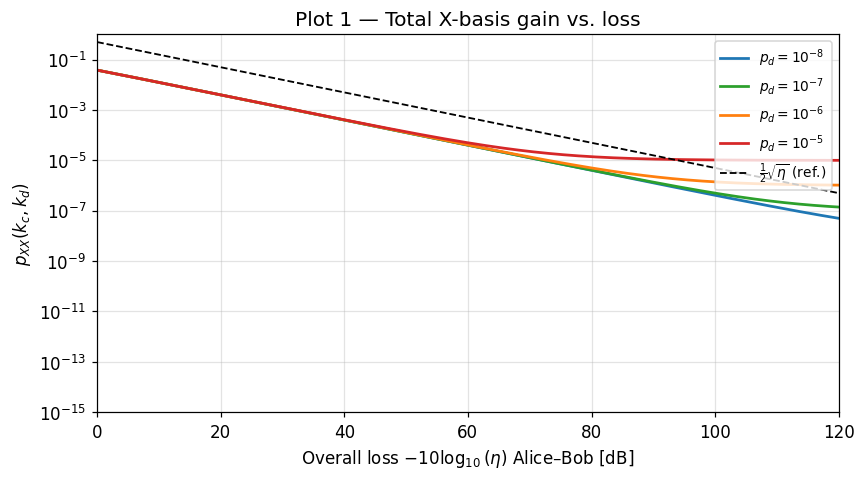

In [12]:
# ─────────────────────────────────────────────────────────────
# PLOT 1 — Total X-basis gain p_XX vs. loss
#          for multiple dark-count rates
# ─────────────────────────────────────────────────────────────
loss_arr = PARAMS['loss_dB_range']
eta_arr  = dB_to_eta(loss_arr)
alpha    = PARAMS['alpha']
phi      = PARAMS['phi']
theta    = PARAMS['theta']
gamma_arr = np.sqrt(eta_arr) * alpha**2

fig, ax = plt.subplots(figsize=(8, 4.5))

pd_values = [1e-8, 1e-7, 1e-6, 1e-5]
colors    = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

for pd_val, color in zip(pd_values, colors):
    pXX = p_xx_total(phi, theta, gamma_arr, pd_val)
    ax.semilogy(loss_arr, pXX, color=color, label=f'$p_d = 10^{{{int(np.log10(pd_val))}}}$')

# PLOB-like reference: √η / 2  (single-photon from one side)
ax.semilogy(loss_arr, 0.5 * np.sqrt(eta_arr), 'k--', lw=1.2, label='$\\frac{1}{2}\\sqrt{\\eta}$ (ref.)')

ax.set_xlabel('Overall loss $-10\\log_{10}(\\eta)$ Alice–Bob [dB]')
ax.set_ylabel('$p_{XX}(k_c,k_d)$')
ax.set_title('Plot 1 — Total X-basis gain vs. loss')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 120)
ax.set_ylim(1e-15, 1)
plt.tight_layout()
plt.show()

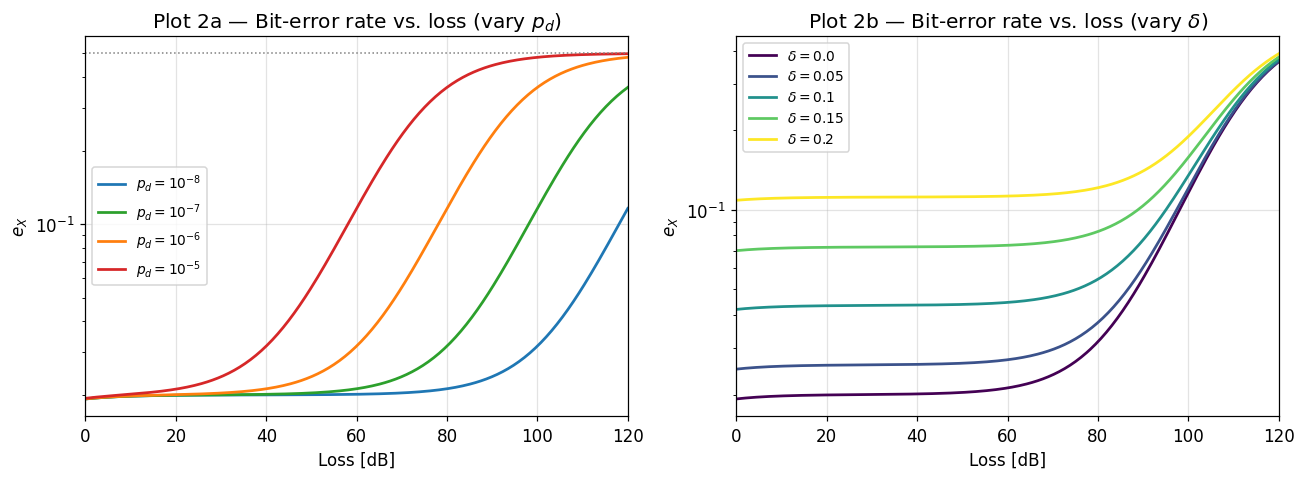

In [13]:
# ─────────────────────────────────────────────────────────────
# PLOT 2 — X-basis bit-error rate e_X vs. loss
#          for multiple dark-count rates and phase mismatches
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# -- Left panel: varying dark count rate at δ=0 ---------------
ax = axes[0]
for pd_val, color in zip(pd_values, colors):
    eX = bit_error_rate(phi, theta, gamma_arr, pd_val)
    eX = np.clip(eX, 0.0, 0.5)
    ax.semilogy(loss_arr, eX, color=color, label=f'$p_d=10^{{{int(np.log10(pd_val))}}}$')

ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Loss [dB]')
ax.set_ylabel('$e_X$')
ax.set_title('Plot 2a — Bit-error rate vs. loss (vary $p_d$)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)

# -- Right panel: varying phase mismatch δ, fixed pd ----------
ax = axes[1]
delta_vals = [0.0, 0.05, 0.10, 0.15, 0.20]
cmap = plt.cm.viridis
for i, dv in enumerate(delta_vals):
    phi_v = dv * np.pi
    eX = bit_error_rate(phi_v, theta, gamma_arr, PARAMS['pd'])
    eX = np.clip(eX, 0.0, 0.5)
    ax.semilogy(loss_arr, eX, color=cmap(i / (len(delta_vals)-1)),
                label=f'$\\delta={dv}$')

ax.set_xlabel('Loss [dB]')
ax.set_ylabel('$e_X$')
ax.set_title('Plot 2b — Bit-error rate vs. loss (vary $\\delta$)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)

plt.tight_layout()
plt.show()

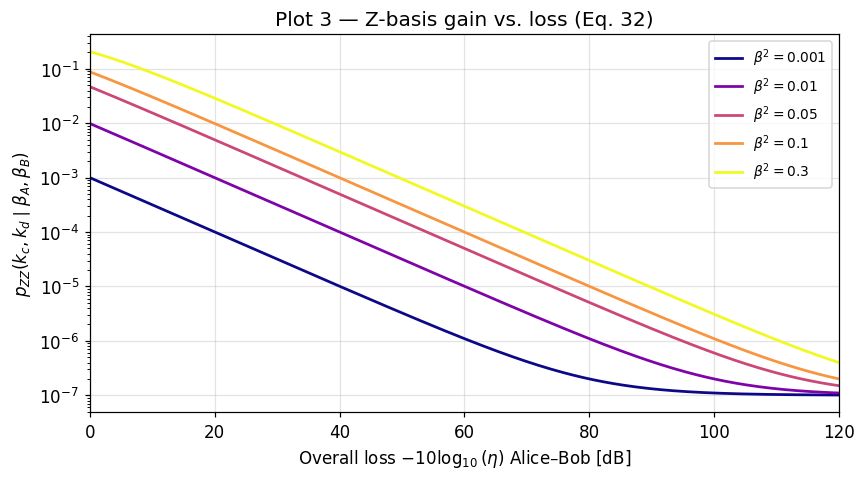

In [14]:
# ─────────────────────────────────────────────────────────────
# PLOT 3 — Z-basis gain p_ZZ vs. loss
#          for several decoy intensities β²
# ─────────────────────────────────────────────────────────────
beta2_vals = [0.001, 0.01, 0.05, 0.1, 0.3]
fig, ax = plt.subplots(figsize=(8, 4.5))

cmap2 = plt.cm.plasma
for i, b2 in enumerate(beta2_vals):
    beta = np.sqrt(b2)
    pZZ  = p_zz_beta(beta, beta, theta, eta_arr, PARAMS['pd'])
    ax.semilogy(loss_arr, pZZ, color=cmap2(i / (len(beta2_vals)-1)),
                label=f'$\\beta^2={b2}$')

ax.set_xlabel('Overall loss $-10\\log_{10}(\\eta)$ Alice–Bob [dB]')
ax.set_ylabel('$p_{ZZ}(k_c,k_d\\mid\\beta_A,\\beta_B)$')
ax.set_title('Plot 3 — Z-basis gain vs. loss (Eq. 32)')
ax.legend(fontsize=9)
ax.set_xlim(0, 120)
plt.tight_layout()
plt.show()

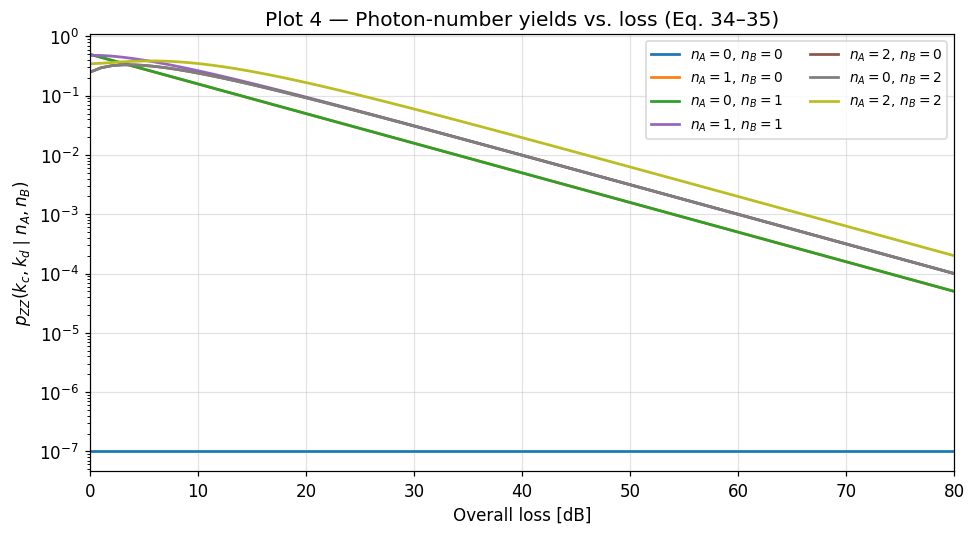


Note: (1,0) and (0,1) yields are equal by symmetry (θ_A=−θ_B here).
Note: (1,0) and (0,1) do NOT contribute to the phase-error rate (paper §4).


In [15]:
# ─────────────────────────────────────────────────────────────
# PLOT 4 — Photon-number yields p_ZZ(nA, nB | η)
#          as a function of loss for selected (nA, nB) pairs
#
# Only evaluated for small photon numbers (low-loss range)
# as the nested loop in Eq. (35) becomes slow for large nA+nB.
# ─────────────────────────────────────────────────────────────
loss_short = np.linspace(0, 80, 80)   # coarser grid for speed
eta_short  = dB_to_eta(loss_short)

photon_pairs = [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 2)]
cmap3 = plt.cm.tab10

fig, ax = plt.subplots(figsize=(9, 5))

for i, (nA, nB) in enumerate(photon_pairs):
    yield_arr = p_zz_photon(nA, nB, thetaA, thetaB, eta_short, PARAMS['pd'])
    ax.semilogy(
        loss_short, yield_arr,
        color=cmap3(i / len(photon_pairs)),
        label=f'$n_A={nA},\\,n_B={nB}$'
    )

ax.set_xlabel('Overall loss [dB]')
ax.set_ylabel('$p_{ZZ}(k_c,k_d\\mid n_A,n_B)$')
ax.set_title('Plot 4 — Photon-number yields vs. loss (Eq. 34–35)')
ax.legend(fontsize=9, ncol=2)
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()
print('\nNote: (1,0) and (0,1) yields are equal by symmetry (θ_A=−θ_B here).')
print('Note: (1,0) and (0,1) do NOT contribute to the phase-error rate (paper §4).')

In [17]:
# ─────────────────────────────────────────────────────────────
# PHASE 1 SUMMARY
# ─────────────────────────────────────────────────────────────
print('=' * 60)
print('TF-QKD Phase 1 — Implementation Summary')
print('Author: Anand Ambastha')
print('=' * 60)
print()
print('Functions implemented:')
funcs = [
    ('h(x)',                   'Binary entropy  [safe at 0, 1]'),
    ('omega(φ, θ)',             'Ω = cos φ · cos θ'),
    ('f_plus / f_minus',        'Gain functions f±  (Eq. 29)'),
    ('q_xx',                   'X-basis gain w/o dark counts  (Eq. 28)'),
    ('p_xx_conditional',       'Conditional X-basis gain  (Eq. 27)'),
    ('p_xx_total',             'Total X-basis gain  (Eq. 30)'),
    ('bit_error_rate',         'X-basis BER  (Eq. 31)'),
    ('q_zz',                   'Z-basis gain w/o dark counts  (Eq. 33)'),
    ('p_zz_beta',              'Z-basis gain  (Eq. 32)'),
    ('p_zz_photon',            'Photon-number yield  (Eq. 34)'),
    ('transmission_factor',    'Eq. (35) Helper 1'),
    ('beamsplitter_factor',    'Eq. (35) Helper 2'),
    ('combinatorial_factor',   'Eq. (35) Helper 3'),
    ('polarization_factor',    'Eq. (35) Helper 4'),
    ('interference_term',      'Eq. (35) Helper 5'),
    ('qzz_photon_number',      'Full Eq. (35) assembled from helpers'),
]
for name, desc in funcs:
    print(f'  {name:<28s} {desc}')

TF-QKD Phase 1 — Implementation Summary
Author: Anand Ambastha

Functions implemented:
  h(x)                         Binary entropy  [safe at 0, 1]
  omega(φ, θ)                  Ω = cos φ · cos θ
  f_plus / f_minus             Gain functions f±  (Eq. 29)
  q_xx                         X-basis gain w/o dark counts  (Eq. 28)
  p_xx_conditional             Conditional X-basis gain  (Eq. 27)
  p_xx_total                   Total X-basis gain  (Eq. 30)
  bit_error_rate               X-basis BER  (Eq. 31)
  q_zz                         Z-basis gain w/o dark counts  (Eq. 33)
  p_zz_beta                    Z-basis gain  (Eq. 32)
  p_zz_photon                  Photon-number yield  (Eq. 34)
  transmission_factor          Eq. (35) Helper 1
  beamsplitter_factor          Eq. (35) Helper 2
  combinatorial_factor         Eq. (35) Helper 3
  polarization_factor          Eq. (35) Helper 4
  interference_term            Eq. (35) Helper 5
  qzz_photon_number            Full Eq. (35) assembled from help